# **Customer Churn Analytics & Business Intelligence:**

# **Business Problem**

   Customer churn is one of the biggest challenges for subscription-based businesses. Every customer who leaves results in lost revenue and increased acquisition costs. This project analyzes customer demographics, service usage, payment behavior, and contract information to identify churn patterns and provide actionable business recommendations.

# **Objectives**

*   Understand customer profile
*   Analyze churn behavior
*   Find factors influencing churn
*   Discover high-risk customer groups
*   Provide business recommendations
















**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [41]:
plt.style.use('ggplot')
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

**Load Dataset**

In [7]:
from google.colab import files

uploaded = files.upload()

Saving customer_churn_analytics_1000.csv to customer_churn_analytics_1000.csv


# **Data Understanding**

In [9]:
import pandas as pd

df = pd.read_csv("customer_churn_analytics_1000.csv")
df.head()

,CustomerID,Gender,SeniorCitizen,Age,Partner,Dependents,TenureMonths,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,SupportTickets,NumServices,LatePayments,JoinDate,Churn
0,CUST0001,Male,0,50,No,Yes,14,No,Month-to-month,Electronic check,47.50,628.19,10,0,1,2024-08-11,Yes
1,CUST0002,Male,1,23,No,No,69,Fiber optic,Month-to-month,Mailed check,64.92,4280.76,7,0,2,2024-12-10,Yes
2,CUST0003,Female,1,54,Yes,No,44,No,One year,Electronic check,100.71,4634.84,4,5,0,2025-09-25,No
3,CUST0004,Male,1,41,No,No,5,Fiber optic,One year,Electronic check,97.31,533.77,6,1,2,2025-01-08,No
4,CUST0005,Male,1,70,No,Yes,9,Fiber optic,One year,Credit card,37.11,349.30,1,2,3,2024-02-27,No


In [10]:
df.shape

(1000, 17)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   object 
 1   Gender           1000 non-null   object 
 2   SeniorCitizen    1000 non-null   int64  
 3   Age              1000 non-null   int64  
 4   Partner          1000 non-null   object 
 5   Dependents       1000 non-null   object 
 6   TenureMonths     1000 non-null   int64  
 7   InternetService  1000 non-null   object 
 8   Contract         1000 non-null   object 
 9   PaymentMethod    1000 non-null   object 
 10  MonthlyCharges   1000 non-null   float64
 11  TotalCharges     1000 non-null   float64
 12  SupportTickets   1000 non-null   int64  
 13  NumServices      1000 non-null   int64  
 14  LatePayments     1000 non-null   int64  
 15  JoinDate         1000 non-null   object 
 16  Churn            1000 non-null   object 
dtypes: float64(2), 

In [12]:
df.describe()

,SeniorCitizen,Age,TenureMonths,MonthlyCharges,TotalCharges,SupportTickets,NumServices,LatePayments
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.508000,45.50700,36.492000,70.089310,2544.186500,5.616000,2.449000,1.488000
std,0.500186,16.93336,20.953448,28.186702,1884.593717,2.855293,1.715325,1.137167
min,0.000000,18.00000,0.000000,20.140000,21.870000,1.000000,0.000000,0.000000
25%,0.000000,31.00000,18.000000,45.742500,1054.290000,3.000000,1.000000,0.000000
50%,1.000000,44.00000,37.000000,71.085000,2036.595000,6.000000,2.000000,1.000000
75%,1.000000,61.00000,55.000000,93.182500,3878.747500,8.000000,4.000000,3.000000
max,1.000000,75.00000,72.000000,119.840000,8008.160000,10.000000,5.000000,3.000000


In [14]:
df.columns

Index(['CustomerID', 'Gender', 'SeniorCitizen', 'Age', 'Partner', 'Dependents',
       'TenureMonths', 'InternetService', 'Contract', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'SupportTickets', 'NumServices',
       'LatePayments', 'JoinDate', 'Churn'],
      dtype='object')

# **Data Cleaning**

In [15]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
SeniorCitizen,0
Age,0
Partner,0
Dependents,0
TenureMonths,0
InternetService,0
Contract,0
PaymentMethod,0


In [23]:
#Handle Missing Values
df['TotalCharges'].fillna(df['TotalCharges'].median())


,TotalCharges
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
995,NaN
996,NaN
997,NaN
998,NaN


In [24]:
#Remove Duplicates
df.duplicated().sum()

np.int64(0)

In [26]:
df.drop_duplicates(inplace=True)

In [27]:
#check datatypes
df.dtypes

,0
CustomerID,object
Gender,object
SeniorCitizen,int64
Age,int64
Partner,object
Dependents,object
TenureMonths,int64
InternetService,object
Contract,object
PaymentMethod,object


In [29]:
df['TotalCharges']=df['TotalCharges'].astype(float)

In [30]:
#Check Unique values
for col in df.select_dtypes(include='object'):
    print(col)
    print(df[col].unique())

CustomerID
['CUST0001' 'CUST0002' 'CUST0003' 'CUST0004' 'CUST0005' 'CUST0006'
 'CUST0007' 'CUST0008' 'CUST0009' 'CUST0010' 'CUST0011' 'CUST0012'
 'CUST0013' 'CUST0014' 'CUST0015' 'CUST0016' 'CUST0017' 'CUST0018'
 'CUST0019' 'CUST0020' 'CUST0021' 'CUST0022' 'CUST0023' 'CUST0024'
 'CUST0025' 'CUST0026' 'CUST0027' 'CUST0028' 'CUST0029' 'CUST0030'
 'CUST0031' 'CUST0032' 'CUST0033' 'CUST0034' 'CUST0035' 'CUST0036'
 'CUST0037' 'CUST0038' 'CUST0039' 'CUST0040' 'CUST0041' 'CUST0042'
 'CUST0043' 'CUST0044' 'CUST0045' 'CUST0046' 'CUST0047' 'CUST0048'
 'CUST0049' 'CUST0050' 'CUST0051' 'CUST0052' 'CUST0053' 'CUST0054'
 'CUST0055' 'CUST0056' 'CUST0057' 'CUST0058' 'CUST0059' 'CUST0060'
 'CUST0061' 'CUST0062' 'CUST0063' 'CUST0064' 'CUST0065' 'CUST0066'
 'CUST0067' 'CUST0068' 'CUST0069' 'CUST0070' 'CUST0071' 'CUST0072'
 'CUST0073' 'CUST0074' 'CUST0075' 'CUST0076' 'CUST0077' 'CUST0078'
 'CUST0079' 'CUST0080' 'CUST0081' 'CUST0082' 'CUST0083' 'CUST0084'
 'CUST0085' 'CUST0086' 'CUST0087' 'CUST0088' 'CUST0

In [33]:
df['Gender']=df['Gender'].str.title()

# **Outlier Detection**

<Axes: ylabel='MonthlyCharges'>

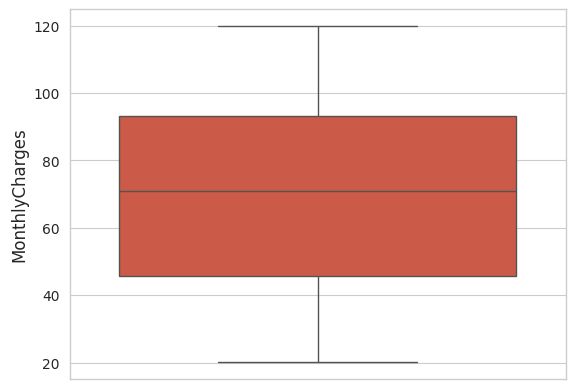

In [34]:
sns.boxplot(df['MonthlyCharges'])

# **Feature Engineering**

**Spending Category**

In [38]:
df['SpendCategory']=pd.qcut(
    df['MonthlyCharges'],
    q=3,
    labels=["Low","Medium","High"]
)

# **Exploratory Data Analysis**

**1. Overall Churn Distribution**

**How many customers stayed and how many customers churned?**

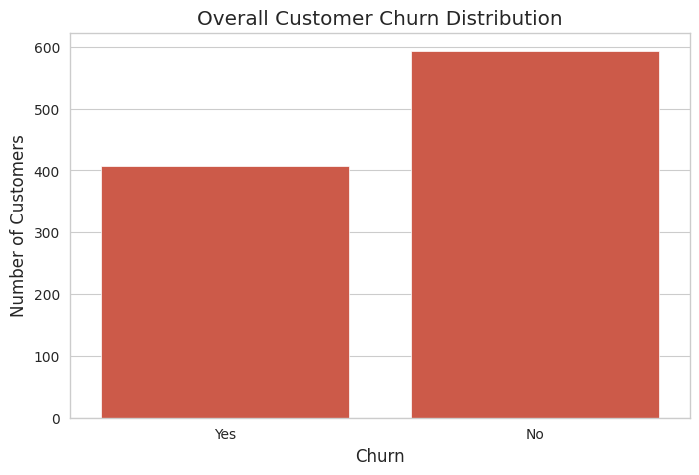

In [42]:
sns.countplot(x='Churn', data=df)

plt.title("Overall Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

**Interpretation**

*   This chart shows the overall distribution of customers who stayed and those who left.
*   If the number of "No" customers is much larger than "Yes", most customers are retained.

*   If churn is high, improving customer retention should become a business priority.









**2. Churn Rate**

**What percentage of customers have churned?**

Churn
No     59.3
Yes    40.7
Name: proportion, dtype: float64


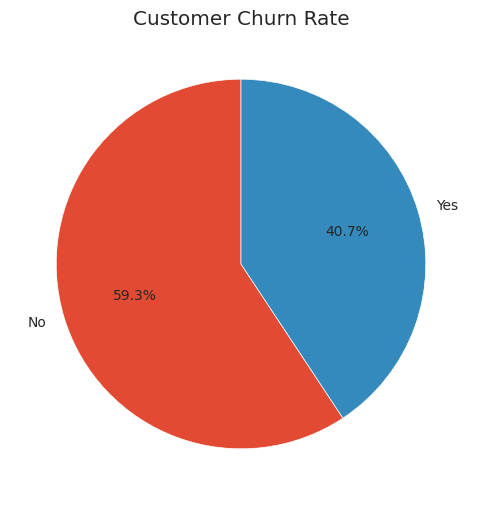

In [43]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100

print(churn_rate)

plt.figure(figsize=(6,6))

plt.pie(
    churn_rate,
    labels=churn_rate.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Customer Churn Rate")

plt.show()

**Interpretation**

*   The pie chart displays the percentage of customers who stayed versus those who churned.
*   A high churn percentage indicates potential issues with pricing, services, or customer satisfaction.



**3. Gender Distribution**